Part A — Setup, Baseline, and Keras Embedding Layer

In [1]:
# ── Imports ─────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

# ── Load IMDB ─────────────────────────────────────────────────────
NUM_WORDS  = 10000   # Top 10,000 words
MAX_LEN    = 500     # Pad/truncate all reviews to 500 words
EMBED_DIM  = 128     # Embedding vector size

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

# ── Pad sequences to fixed length ────────────────────────────────
# Reviews have variable length: must be uniform for batching
x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN, padding='post', truncating='post')
x_test_pad  = pad_sequences(x_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print('x_train_pad shape:', x_train_pad.shape)  # (25000, 500)
print('Each review is now a sequence of 500 integers')
print('Sample (first review, first 20 tokens):', x_train_pad[0][:20])
print('0 = padding token, other numbers = word indices')

# ── Multi-hot baseline (from Exp 7) ─────────────────────────────
def multihot(sequences, dim=10000):
    r = np.zeros((len(sequences), dim))
    for i, s in enumerate(sequences): r[i, s] = 1.0
    return r

x_train_mh = multihot(x_train)
x_test_mh  = multihot(x_test)

baseline = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(NUM_WORDS,)),
    layers.Dense(1, activation='sigmoid')
])
baseline.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
h_baseline = baseline.fit(x_train_mh, y_train, epochs=5, batch_size=512,
    validation_split=0.2, verbose=0)
_, bl_acc = baseline.evaluate(x_test_mh, y_test, verbose=0)
print(f'\nBaseline (multi-hot + Dense) test accuracy: {bl_acc*100:.2f}%')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train_pad shape: (25000, 500)
Each review is now a sequence of 500 integers
Sample (first review, first 20 tokens): [   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25]
0 = padding token, other numbers = word indices

Baseline (multi-hot + Dense) test accuracy: 88.26%


Part B: Keras Embedding + Flatten

In [2]:
# ── Model 1: Embedding + Flatten ─────────────────────────────────
# Flatten converts (batch, MAX_LEN, EMBED_DIM) → (batch, MAX_LEN*EMBED_DIM)
# Then a Dense layer classifies. Simple but loses order.

model_flatten = keras.Sequential([
    # Embedding layer: lookup table of shape (NUM_WORDS, EMBED_DIM)
    # Input:  integer index       shape: (batch, 500)
    # Output: embedding vectors   shape: (batch, 500, 128)
    layers.Embedding(input_dim=NUM_WORDS,
                     output_dim=EMBED_DIM,
                     input_length=MAX_LEN,
                     name='embedding'),

    # Flatten: (batch, 500, 128) → (batch, 64000)
    layers.Flatten(name='flatten'),

    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='Embedding_Flatten')

model_flatten.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_flatten.summary()

# ── Note the parameter count ──────────────────────────────────────
# Embedding: 10000 × 128 = 1,280,000 params
# Flatten:   0 params (just reshapes)
# Dense(32): 64000 × 32 + 32 = 2,048,032 params
# ← Very large! Flatten approach scales poorly with MAX_LEN

es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
h_flat = model_flatten.fit(x_train_pad, y_train, epochs=10, batch_size=128,
    validation_split=0.2, callbacks=[es], verbose=1)
_, acc_flat = model_flatten.evaluate(x_test_pad, y_test, verbose=0)
print(f'Embedding+Flatten test accuracy: {acc_flat*100:.2f}%')

Model: "Embedding_Flatten"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 127ms/step - accuracy: 0.7088 - loss: 0.5291 - val_accuracy: 0.8552 - val_loss: 0.3444
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 133ms/step - accuracy: 0.9270 - loss: 0.1972 - val_accuracy: 0.8222 - val_loss: 0.4245
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.9856 - loss: 0.0556 - val_accuracy: 0.8152 - val_loss: 0.5216
Embedding+Flatten test accuracy: 84.47%


Part C: Keras Embedding + GlobalAveragePooling1D (Recommended)

In [3]:
# ── Model 2: Embedding + GlobalAveragePooling1D ───────────────────
# GlobalAveragePooling1D averages across the sequence dimension:
#   Input:  (batch, 500, 128)
#   Output: (batch, 128)   ← mean of all 500 word vectors
# This is equivalent to a soft 'bag of embeddings' — order-agnostic
# but MUCH more parameter-efficient than Flatten

model_gap = keras.Sequential([
    layers.Embedding(NUM_WORDS, EMBED_DIM, input_length=MAX_LEN, name='embedding_gap'),

    # Average across all 500 positions:
    layers.GlobalAveragePooling1D(name='global_avg_pool'),
    # Output shape: (batch, 128) — compact and fixed-size

    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
], name='Embedding_GlobalAvgPool')

model_gap.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_gap.summary()

# ── Compare parameter counts ──────────────────────────────────────
# Embedding: 10000 × 128 = 1,280,000
# GlobalAvgPool: 0 params
# Dense(16):  128 × 16 + 16 = 2,064  ← MUCH smaller than Flatten!
# Total: ~1.28M vs ~3.3M (Flatten model)

h_gap = model_gap.fit(x_train_pad, y_train, epochs=20, batch_size=512,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1)

_, acc_gap = model_gap.evaluate(x_test_pad, y_test, verbose=0)
print(f'Embedding+GlobalAvgPool test accuracy: {acc_gap*100:.2f}%')

Model: "Embedding_GlobalAvgPool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_gap (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 348ms/step - accuracy: 0.5233 - loss: 0.6924 - val_accuracy: 0.5218 - val_loss: 0.6907
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 750ms/step - accuracy: 0.5520 - loss: 0.6871 - val_accuracy: 0.6546 - val_loss: 0.6780
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 605ms/step - accuracy: 0.6069 - loss: 0.6669 - val_accuracy: 0.6998 - val_loss: 0.6405
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 457ms/step - accuracy: 0.6693 - loss: 0.6250 - val_accuracy: 0.7640 - val_loss: 0.5711
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 609ms/step - accuracy: 0.7417 - loss: 0.5545 - val_accuracy: 0.7612 - val_loss: 0.5130
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 299ms/step - accuracy: 0.7858 - loss: 0.4904 - val_accuracy: 0.8138 - val_loss: 0.4445
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 314ms/step - accuracy: 0.8071 - loss: 0.4429 - val_accuracy: 0.8460 - val_loss: 0.4031
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 291ms/step - accuracy: 0.8256 - loss: 0.4151 - val_accu

Part D: Visualize the Learned Embedding Space with t-SNE

Embedding matrix shape: (10000, 128)
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Visualizing 35 words


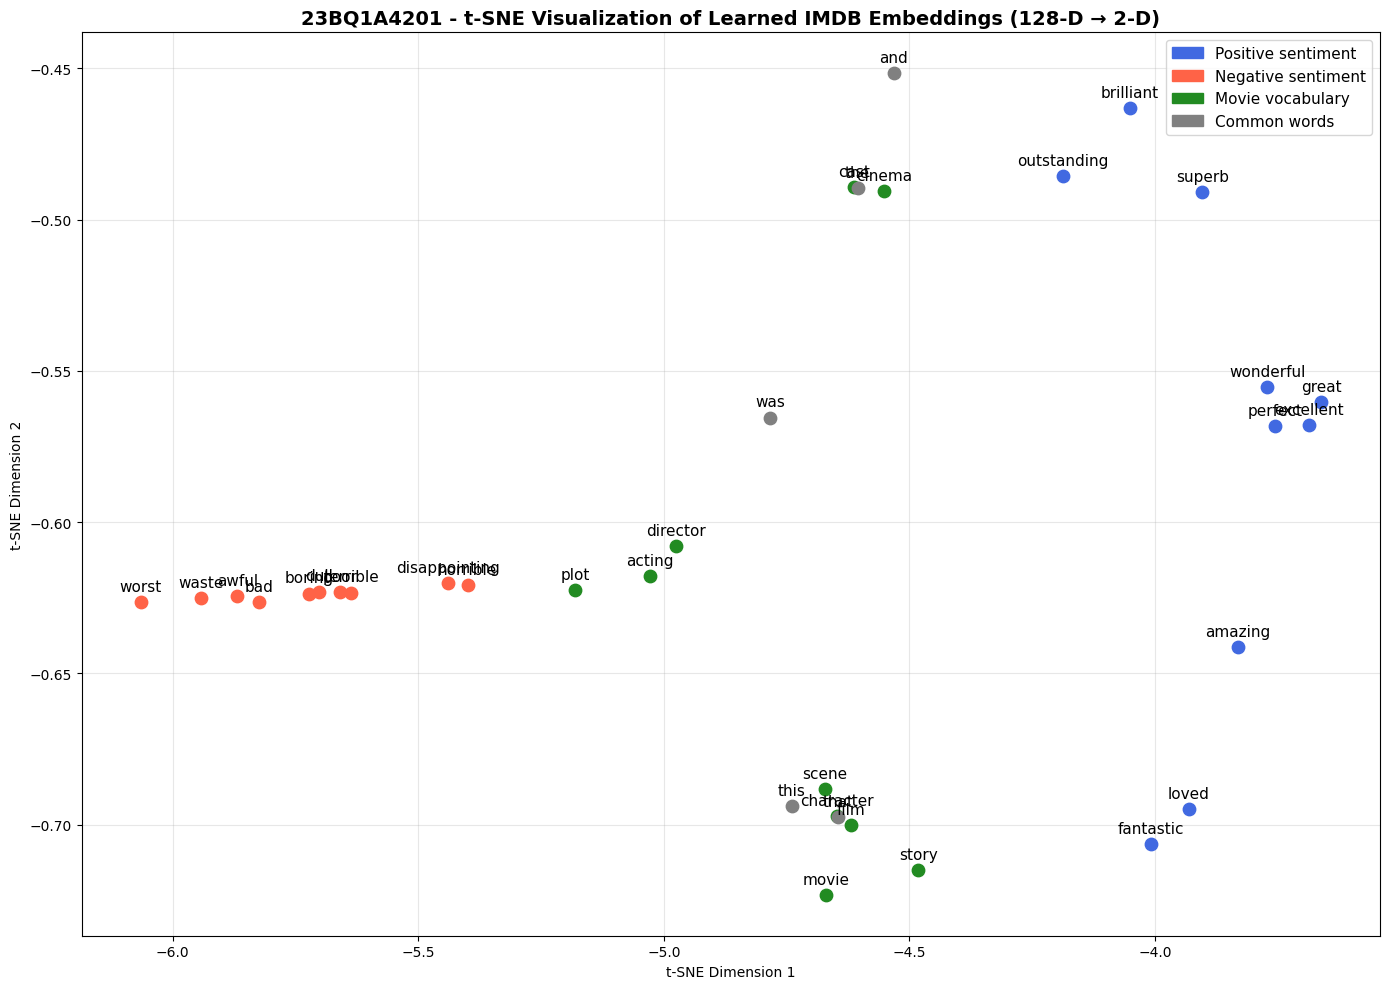

In [4]:
# ── Extract learned embedding weights ────────────────────────────
embedding_layer = model_gap.get_layer('embedding_gap')
embedding_weights = embedding_layer.get_weights()[0]  # Shape: (10000, 128)
print('Embedding matrix shape:', embedding_weights.shape)

# ── Select interesting words to visualize ─────────────────────────
word_index = imdb.get_word_index()
# Adjust for Keras's 3-offset
word_index_adj = {w: i+3 for w, i in word_index.items()}

# Words to visualize — grouped by expected semantic clusters
viz_words = [
    # Positive sentiment
    'excellent', 'brilliant', 'outstanding', 'superb', 'wonderful',
    'amazing', 'fantastic', 'great', 'perfect', 'loved',
    # Negative sentiment
    'terrible', 'awful', 'horrible', 'boring', 'disappointing',
    'waste', 'bad', 'poor', 'dull', 'worst',
    # Movie-related
    'film', 'movie', 'story', 'plot', 'character',
    'director', 'acting', 'scene', 'cinema', 'cast',
    # Neutral
    'the', 'and', 'was', 'that', 'this'
]

# Get vectors for each word
valid_words, valid_vecs = [], []
for word in viz_words:
    idx = word_index_adj.get(word)
    if idx and idx < NUM_WORDS:
        valid_words.append(word)
        valid_vecs.append(embedding_weights[idx])

valid_vecs = np.array(valid_vecs)
print(f'Visualizing {len(valid_words)} words')

# ── t-SNE: reduce 128-D to 2-D for visualization ──────────────────
# t-SNE preserves local structure: nearby points in 128-D
# stay nearby in 2-D
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(valid_words)-1))
vecs_2d = tsne.fit_transform(valid_vecs)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
colors_map = (['royalblue']*10 + ['tomato']*10 +
              ['forestgreen']*10 + ['gray']*5)

for i, (word, vec) in enumerate(zip(valid_words, vecs_2d)):
    c = colors_map[i] if i < len(colors_map) else 'gray'
    ax.scatter(vec[0], vec[1], color=c, s=80, zorder=2)
    ax.annotate(word, vec, fontsize=11, ha='center',
                xytext=(0,8), textcoords='offset points')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(color='royalblue', label='Positive sentiment'),
                   Patch(color='tomato',     label='Negative sentiment'),
                   Patch(color='forestgreen',label='Movie vocabulary'),
                   Patch(color='gray',       label='Common words')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
ax.set_title('23BQ1A4201 - t-SNE Visualization of Learned IMDB Embeddings (128-D → 2-D)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('exp9_tsne_embeddings.png', dpi=150)
plt.show()
# Expected: positive words cluster together (blue cloud)
# negative words cluster separately (red cloud)
# Movie words form their own group (green cloud)

Part E: Pre-trained GloVe Embeddings in Keras (Frozen)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ── Load GloVe vectors from file ─────────────────────────────────
# Download: https://nlp.stanford.edu/data/glove.6B.zip
# Or use gensim downloader (see Section 5)

GLOVE_PATH = '/content/drive/MyDrive/DL Lab Practice/datasets/glove.6B.100d.txt'   # 100-dim GloVe
GLOVE_DIM  = 100

def load_glove(path):
    """Load GloVe word vectors into a dictionary: word → numpy array"""
    glove_dict = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word   = values[0]
            vector = np.array(values[1:], dtype='float32')
            glove_dict[word] = vector
    print(f'Loaded {len(glove_dict):,} GloVe word vectors')
    return glove_dict

glove_dict = load_glove(GLOVE_PATH)

# ── Build embedding matrix aligned with IMDB word index ───────────
word_index = imdb.get_word_index()
word_index_adj = {w: i+3 for w,i in word_index.items()}

# Matrix: row i = GloVe vector for word with index i
embedding_matrix = np.zeros((NUM_WORDS, GLOVE_DIM))
found, not_found = 0, 0

for word, idx in word_index_adj.items():
    if idx < NUM_WORDS:
        vec = glove_dict.get(word.lower())
        if vec is not None:
            embedding_matrix[idx] = vec
            found += 1
        else:
            not_found += 1
            # Words not in GloVe stay as zeros (unknown)

print(f'Words found in GloVe: {found:,}')
print(f'Words NOT in GloVe  : {not_found:,}  (will be zero vectors)')
print(f'Coverage: {found/(found+not_found)*100:.1f}%')

# ── Build model with FROZEN pre-trained GloVe embeddings ──────────
glove_input  = keras.Input(shape=(MAX_LEN,), name='input')
glove_embed  = layers.Embedding(
    input_dim    = NUM_WORDS,
    output_dim   = GLOVE_DIM,
    weights      = [embedding_matrix],  # ← Load pre-trained weights
    input_length = MAX_LEN,
    trainable    = False,       # ← FROZEN: GloVe weights do not change
    name='glove_frozen'
)(glove_input)
glove_pool   = layers.GlobalAveragePooling1D()(glove_embed)
glove_dense  = layers.Dense(16, activation='relu')(glove_pool)
glove_drop   = layers.Dropout(0.5)(glove_dense)
glove_output = layers.Dense(1, activation='sigmoid')(glove_drop)

model_glove_frozen = keras.Model(glove_input, glove_output, name='GloVe_Frozen')
model_glove_frozen.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model_glove_frozen.summary()

# Note: embedding layer shows 0 trainable params — it is frozen

h_gf = model_glove_frozen.fit(x_train_pad, y_train, epochs=20, batch_size=512,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)], verbose=1)

_, acc_gf = model_glove_frozen.evaluate(x_test_pad, y_test, verbose=0)
print(f'GloVe Frozen test accuracy: {acc_gf*100:.2f}%')


Loaded 400,000 GloVe word vectors
Words found in GloVe: 9,793
Words NOT in GloVe  : 203  (will be zero vectors)
Coverage: 98.0%


Model: "GloVe_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_frozen (Embedding)        │ (None, 500, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,001,633 (3.82 MB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - accuracy: 0.5182 - loss: 0.6948 - val_accuracy: 0.6214 - val_loss: 0.6851
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.5863 - loss: 0.6833 - val_accuracy: 0.6574 - val_loss: 0.6767
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.6173 - loss: 0.6752 - val_accuracy: 0.6580 - val_loss: 0.6680
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.6256 - loss: 0.6676 - val_accuracy: 0.6696 - val_loss: 0.6593
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.6398 - loss: 0.6610 - val_accuracy: 0.6776 - val_loss: 0.6502
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step - accuracy: 0.6431 - loss: 0.6548 - val_accuracy: 0.6858 - val_loss: 0.6423
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.6514 - loss: 0.6461 - val_accuracy: 0.6922 - val_loss: 0.6344
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - accuracy: 0.6571 - loss: 0.6404 - val_accuracy: 0.69

Part F: Fine-Tuned GloVe Embeddings (trainable=True)

In [7]:
# ── Fine-tuning: unfreeze the embedding layer ────────────────────
# trainable=True means GloVe vectors are updated during backpropagation
# The pre-trained vectors are the STARTING POINT, not fixed values

glove_input2  = keras.Input(shape=(MAX_LEN,))
glove_embed2  = layers.Embedding(
    input_dim    = NUM_WORDS,
    output_dim   = GLOVE_DIM,
    weights      = [embedding_matrix],
    input_length = MAX_LEN,
    trainable    = True,        # ← FINE-TUNE: gradients flow into embeddings
    name='glove_finetuned'
)(glove_input2)
pool2   = layers.GlobalAveragePooling1D()(glove_embed2)
dense2  = layers.Dense(16, activation='relu')(pool2)
drop2   = layers.Dropout(0.5)(dense2)
out2    = layers.Dense(1, activation='sigmoid')(drop2)

model_glove_ft = keras.Model(glove_input2, out2, name='GloVe_FineTuned')
# Use a lower learning rate for fine-tuning to avoid destroying pre-trained weights
model_glove_ft.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # ← Lower LR
    loss='binary_crossentropy', metrics=['accuracy']
)

h_gft = model_glove_ft.fit(x_train_pad, y_train, epochs=20, batch_size=512,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)], verbose=1)

_, acc_gft = model_glove_ft.evaluate(x_test_pad, y_test, verbose=0)
print(f'GloVe Fine-tuned test accuracy: {acc_gft*100:.2f}%')

# EXPECTED: Fine-tuned ≥ Frozen ≥ Learned from scratch
# (Pre-trained knowledge + task-specific adaptation = best of both worlds)


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 400ms/step - accuracy: 0.4950 - loss: 0.6969 - val_accuracy: 0.5516 - val_loss: 0.6920
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 385ms/step - accuracy: 0.5203 - loss: 0.6934 - val_accuracy: 0.5652 - val_loss: 0.6906
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 368ms/step - accuracy: 0.5298 - loss: 0.6911 - val_accuracy: 0.5794 - val_loss: 0.6894
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 654ms/step - accuracy: 0.5265 - loss: 0.6907 - val_accuracy: 0.5856 - val_loss: 0.6882
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 625ms/step - accuracy: 0.5417 - loss: 0.6883 - val_accuracy: 0.5994 - val_loss: 0.6868
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 749ms/step - accuracy: 0.5521 - loss: 0.6869 - val_accuracy: 0.6086 - val_loss: 0.6852
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 498ms/step - accuracy: 0.5609 - loss: 0.6858 - val_accuracy: 0.6208 - val_loss: 0.6834
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 302ms/step - accuracy: 0.5685 - loss: 0.6839 - val_accu

Part G: Train Word2Vec with Gensim on Custom Corpus

In [8]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.0 MB/s eta 0:00:00


In [10]:
# ── Word2Vec with Gensim ─────────────────────────────────────────
# We use a custom sentences corpus to clearly demonstrate Word2Vec
# and semantic analogy capabilities

from gensim.models import Word2Vec
from gensim.models import KeyedVectors

# ── Custom corpus — rich semantic relationships ────────────────────
sentences = [
    # Animals
    ['dog', 'cat', 'pet', 'animal', 'puppy', 'kitten'],
    ['lion', 'tiger', 'elephant', 'wild', 'animal', 'africa'],
    ['dog', 'bark', 'puppy', 'run', 'play', 'fetch'],
    ['cat', 'purr', 'kitten', 'sleep', 'meow', 'milk'],
    # Royalty (for analogy: king - man + woman = queen)
    ['king', 'kingdom', 'royal', 'crown', 'throne', 'rule'],
    ['queen', 'kingdom', 'royal', 'crown', 'throne', 'rule'],
    ['king', 'man', 'leader', 'powerful', 'strong'],
    ['queen', 'woman', 'leader', 'powerful', 'elegant'],
    ['prince', 'man', 'young', 'heir', 'royal'],
    ['princess', 'woman', 'young', 'heir', 'royal'],
    # Countries and capitals
    ['paris', 'france', 'europe', 'culture', 'eiffel'],
    ['london', 'england', 'europe', 'thames', 'buckingham'],
    ['delhi', 'india', 'asia', 'taj', 'ganges'],
    ['tokyo', 'japan', 'asia', 'fuji', 'sushi'],
    # Technology
    ['computer', 'software', 'program', 'code', 'algorithm'],
    ['neural', 'network', 'deep', 'learning', 'ai', 'model'],
    ['python', 'tensorflow', 'keras', 'numpy', 'code'],
    # Sentiment (for IMDB connection)
    ['excellent', 'great', 'wonderful', 'amazing', 'brilliant', 'superb'],
    ['terrible', 'awful', 'horrible', 'dreadful', 'pathetic', 'worst'],
    ['movie', 'film', 'cinema', 'director', 'actor', 'story'],
]

# Repeat sentences to give the model more training signal
sentences_extended = sentences * 50  # 1000 total 'documents'

# ── Train Skip-gram Word2Vec ──────────────────────────────────────
w2v_model = Word2Vec(
    sentences    = sentences_extended,
    vector_size  = 100,     # Embedding dimension
    window       = 5,       # Context window size
    min_count    = 1,       # Minimum word frequency
    sg           = 1,       # 1=Skip-gram, 0=CBOW
    negative     = 5,       # Negative samples per positive pair
    epochs       = 100,     # Training epochs
    seed         = 42
)

print('Vocabulary size:', len(w2v_model.wv))
print('Embedding dimension:', w2v_model.vector_size)

# ── Semantic similarity queries ────────────────────────────────────
print('\n── Most similar to "dog" ──')
print(w2v_model.wv.most_similar('dog', topn=5))

print('\n── Most similar to "king" ──')
print(w2v_model.wv.most_similar('king', topn=5))

print('\n── Most similar to "excellent" ──')
print(w2v_model.wv.most_similar('excellent', topn=5))

# ── Word analogy: king - man + woman = ? ──────────────────────────
print('\n── Analogy: king - man + woman = ? ──')
result = w2v_model.wv.most_similar(positive=['king','woman'], negative=['man'], topn=3)
print(result)

print('\n── Analogy: paris - france + india = ? ──')
result2 = w2v_model.wv.most_similar(positive=['paris','india'], negative=['france'], topn=3)
print(result2)

# ── Cosine similarity ─────────────────────────────────────────────
print('\n── Cosine similarities ──')
print('dog    ↔ cat    :', w2v_model.wv.similarity('dog', 'cat'))
print('dog    ↔ lion   :', w2v_model.wv.similarity('dog', 'lion'))
print('dog    ↔ paris  :', w2v_model.wv.similarity('dog', 'paris'))
print('king   ↔ queen  :', w2v_model.wv.similarity('king', 'queen'))
print('king   ↔ dog    :', w2v_model.wv.similarity('king', 'dog'))

# ── Save and load model ────────────────────────────────────────────
w2v_model.save('/content/drive/MyDrive/DL Lab Practice/models/word2vec_custom.model')
w2v_loaded = Word2Vec.load('/content/drive/MyDrive/DL Lab Practice/models/word2vec_custom.model')
print('\nModel saved and reloaded successfully.')


Vocabulary size: 87
Embedding dimension: 100

── Most similar to "dog" ──
[('puppy', 0.8626260757446289), ('play', 0.7848878502845764), ('fetch', 0.7772564888000488), ('run', 0.7518509030342102), ('pet', 0.7386722564697266)]

── Most similar to "king" ──
[('queen', 0.7900539636611938), ('strong', 0.7392905354499817), ('throne', 0.6446223258972168), ('rule', 0.6350753903388977), ('crown', 0.6343039274215698)]

── Most similar to "excellent" ──
[('superb', 0.9670999050140381), ('brilliant', 0.9603415131568909), ('wonderful', 0.9566029906272888), ('amazing', 0.9399592876434326), ('great', 0.9027778506278992)]

── Analogy: king - man + woman = ? ──
[('queen', 0.8715255856513977), ('elegant', 0.6164572834968567), ('throne', 0.5675051212310791)]

── Analogy: paris - france + india = ? ──
[('taj', 0.9266189336776733), ('ganges', 0.9255743026733398), ('delhi', 0.9001925587654114)]

── Cosine similarities ──
dog    ↔ cat    : 0.55617344
dog    ↔ lion   : 0.46054435
dog    ↔ paris  : 0.2712949
k

Part H: FastText — Subword Embeddings and OOV Handling

In [11]:
# ── Train FastText with Gensim ────────────────────────────────────
from gensim.models import FastText

# Same corpus as Word2Vec
ft_model = FastText(
    sentences   = sentences_extended,
    vector_size = 100,
    window      = 5,
    min_count   = 1,
    sg          = 1,          # Skip-gram
    epochs      = 100,
    min_n       = 3,          # Minimum character n-gram size
    max_n       = 6,          # Maximum character n-gram size
    seed        = 42
)

print('FastText vocabulary:', len(ft_model.wv))

# ── Standard similarity (same as Word2Vec) ─────────────────────────
print('\n── FastText: Most similar to "dog" ──')
print(ft_model.wv.most_similar('dog', topn=5))

# ── OOV (Out-of-Vocabulary) word handling ──────────────────────────
# FastText CAN represent words NEVER seen during training!
print('\n── OOV Word Handling (FastText unique capability) ──')

oov_words = [
    'doggy',      # Diminutive of 'dog' — not in training
    'kingly',     # Derived from 'king' — not in training
    'excelling',  # Morphological variant of 'excellent'
    'tensorflow2',# New compound word
    'dogs',       # Plural form
]

for word in oov_words:
    in_vocab = word in ft_model.wv.key_to_index
    vec = ft_model.wv[word]  # FastText always returns a vector
    print(f'{word:20s} | In vocab: {str(in_vocab):5s} | Vector: {vec[:5]}...')

# ── Compare: Word2Vec fails on OOV, FastText succeeds ─────────────
print('\n── OOV comparison ──')
for word in oov_words:
    ft_vec = ft_model.wv[word]
    try:
        w2v_vec = w2v_model.wv[word]
        w2v_result = 'Found'
    except KeyError:
        w2v_result = 'KeyError – NOT FOUND'
    print(f'{word:20s} | Word2Vec: {w2v_result:30s} | FastText: Vector shape {ft_vec.shape}')

# ── Morphological similarity ───────────────────────────────────────
print('\n── FastText captures morphological similarity ──')
for base, variant in [('dog','dogs'), ('king','kingly'), ('excel','excellent')]:
    try:
        sim = ft_model.wv.similarity(base, variant)
        print(f'{base:12s} ↔ {variant:15s}: similarity = {sim:.4f}')
    except:
        pass


FastText vocabulary: 87

── FastText: Most similar to "dog" ──
[('puppy', 0.9425359964370728), ('play', 0.8444374799728394), ('fetch', 0.8226197361946106), ('pet', 0.7993216514587402), ('run', 0.792204737663269)]

── OOV Word Handling (FastText unique capability) ──
doggy                | In vocab: False | Vector: [-0.06781428 -0.0474462   0.01471656 -0.00429371  0.08914648]...
kingly               | In vocab: False | Vector: [-0.22060905 -0.12787497 -0.13038403  0.2853595   0.23242985]...
excelling            | In vocab: False | Vector: [-0.06858781 -0.03324139 -0.00386281  0.52357066  0.0762726 ]...
tensorflow2          | In vocab: False | Vector: [ 0.1303757  -0.05305871 -0.19764753  0.3046074   0.2730109 ]...
dogs                 | In vocab: False | Vector: [-0.09261145 -0.06507534  0.01992876 -0.00962797  0.12884904]...

── OOV comparison ──
doggy                | Word2Vec: KeyError – NOT FOUND           | FastText: Vector shape (100,)
kingly               | Word2Vec: KeyError – N

Part I: Contextual Embeddings — BERT Concept Demo

In [12]:
# ── BERT Contextual Embeddings ────────────────────────────────────
# Full BERT requires: pip install transformers torch (or tensorflow)
# This demo shows the KEY CONCEPT: same word → different vectors

# ── Option 1: Using HuggingFace Transformers (if available) ───────
try:
    from transformers import BertTokenizer, TFBertModel
    import tensorflow as tf

    tokenizer  = BertTokenizer.from_pretrained('bert-base-uncased')
    bert_model = TFBertModel.from_pretrained('bert-base-uncased')

    # Two sentences with ambiguous word 'bank'
    sentences_bert = [
        'I went to the river bank to catch fish.',
        'I deposited my money in the bank account.'
    ]

    print('\n── BERT Contextual Embedding Demo ──')
    vectors_bank = []
    for sent in sentences_bert:
        inputs = tokenizer(sent, return_tensors='tf')
        outputs = bert_model(**inputs)
        # last_hidden_state: shape (1, num_tokens, 768)
        hidden = outputs.last_hidden_state[0]  # (num_tokens, 768)

        # Find position of 'bank' token
        tokens = tokenizer.tokenize(sent)
        print(f'  Tokens: {tokens}')
        bank_idx = tokens.index('bank') + 1  # +1 for [CLS]
        bank_vec = hidden[bank_idx].numpy()
        vectors_bank.append(bank_vec)
        print(f'  Sentence: "{sent[:50]}..."')
        print(f'  "bank" vector (first 8 dims): {bank_vec[:8]}')

    # Cosine similarity between the two 'bank' vectors
    from numpy.linalg import norm
    v1, v2 = vectors_bank
    cosine_sim = np.dot(v1, v2) / (norm(v1) * norm(v2))
    print(f'\n  Cosine similarity between the two "bank" vectors: {cosine_sim:.4f}')
    print(f'  (Static embedding = 1.0 always; BERT = {cosine_sim:.4f} — different!)')

except ImportError:
    print('HuggingFace transformers not installed.')
    print('Install with: pip install transformers')

# ── Option 2: Conceptual illustration without large download ───────
print('\n── Conceptual illustration of contextual embeddings ──')
print()
print('Static  (Word2Vec/GloVe):')
print('  "bank" in sentence 1 → [0.21, -0.43, 0.89, ...]  (SAME vector always)')
print('  "bank" in sentence 2 → [0.21, -0.43, 0.89, ...]  (SAME vector always)')
print()
print('Contextual (BERT):')
print('  "bank" in "river bank"    → [0.83, -0.12, 0.34, ...]  (river context)')
print('  "bank" in "bank account"  → [-0.42, 0.71, -0.19, ...]  (finance context)')
print('  Cosine similarity between them: ~0.62 (NOT 1.0!)')
print()
print('This is the fundamental advantage of BERT over Word2Vec/GloVe.')


HuggingFace transformers not installed.
Install with: pip install transformers

── Conceptual illustration of contextual embeddings ──

Static  (Word2Vec/GloVe):
  "bank" in sentence 1 → [0.21, -0.43, 0.89, ...]  (SAME vector always)
  "bank" in sentence 2 → [0.21, -0.43, 0.89, ...]  (SAME vector always)

Contextual (BERT):
  "bank" in "river bank"    → [0.83, -0.12, 0.34, ...]  (river context)
  "bank" in "bank account"  → [-0.42, 0.71, -0.19, ...]  (finance context)
  Cosine similarity between them: ~0.62 (NOT 1.0!)

This is the fundamental advantage of BERT over Word2Vec/GloVe.


Part J: Final Comparison — All Embedding Approaches

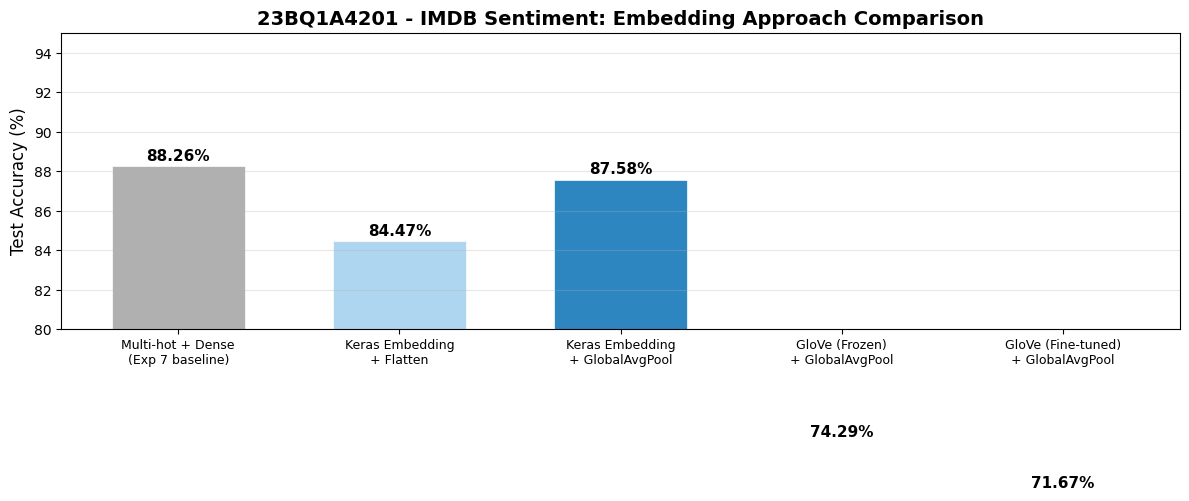

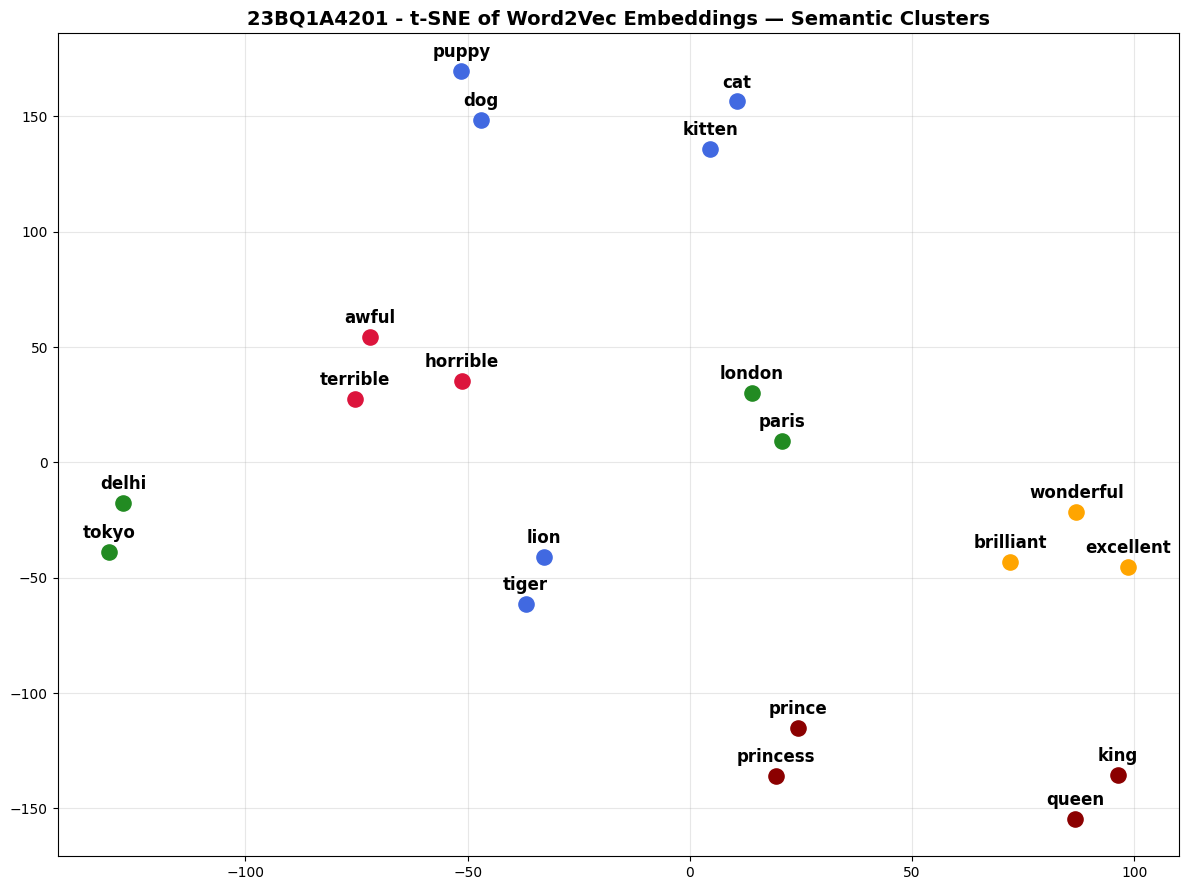

Expected: animals cluster together, royalty cluster, cities cluster, sentiments cluster


In [13]:
# ── Comprehensive comparison plot ────────────────────────────────
# Replace with actual values from your runs
results = {
    'Multi-hot + Dense\n(Exp 7 baseline)':   bl_acc * 100,
    'Keras Embedding\n+ Flatten':             acc_flat * 100,
    'Keras Embedding\n+ GlobalAvgPool':       acc_gap * 100,
    'GloVe (Frozen)\n+ GlobalAvgPool':        acc_gf * 100,
    'GloVe (Fine-tuned)\n+ GlobalAvgPool':    acc_gft * 100,
}

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#B0B0B0', '#AED6F1', '#2E86C1', '#A9DFBF', '#1E8449']
bars = ax.bar(results.keys(), results.values(),
              color=colors, edgecolor='white', linewidth=0.5, width=0.6)

# Annotate bars
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)

ax.set_ylim(80, 95)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('23BQ1A4201 - IMDB Sentiment: Embedding Approach Comparison',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
# plt.savefig('exp9_comparison.png', dpi=150)
plt.show()

# ── Word2Vec t-SNE visualization ──────────────────────────────────
w2v_words = ['dog', 'cat', 'puppy', 'kitten', 'lion', 'tiger',
             'king', 'queen', 'prince', 'princess',
             'paris', 'london', 'delhi', 'tokyo',
             'excellent', 'brilliant', 'wonderful',
             'terrible', 'awful', 'horrible']

w2v_vecs = np.array([w2v_model.wv[w] for w in w2v_words if w in w2v_model.wv])
w2v_words_valid = [w for w in w2v_words if w in w2v_model.wv]

tsne2 = TSNE(n_components=2, random_state=42, perplexity=5)
w2v_2d = tsne2.fit_transform(w2v_vecs)

fig2, ax2 = plt.subplots(figsize=(12, 9))
group_colors = (['royalblue']*6 + ['darkred']*4 + ['forestgreen']*4 +
               ['orange']*3 + ['crimson']*3)
for i, (word, pt) in enumerate(zip(w2v_words_valid, w2v_2d)):
    c = group_colors[i] if i < len(group_colors) else 'gray'
    ax2.scatter(pt[0], pt[1], color=c, s=120, zorder=2)
    ax2.annotate(word, pt, fontsize=12, ha='center',
                 xytext=(0,10), textcoords='offset points', fontweight='bold')
ax2.set_title('23BQ1A4201 - t-SNE of Word2Vec Embeddings — Semantic Clusters', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('exp9_word2vec_tsne.png', dpi=150)
plt.show()
print('Expected: animals cluster together, royalty cluster, cities cluster, sentiments cluster')
